# Spiral Notebook: Three Passes Through Quantum Autoresearch

We are going to run an automated quantum experiment optimizer. **First time through, you just watch.** Second time, you will understand what you are watching. Third time, you will drive.

Each pass covers the *entire* system at increasing depth -- like zooming into a fractal where each pass reveals structure that was invisible before.

---
# Pass 1: The 5-Minute Demo

You do not need to understand anything yet. The goal is: **run the machine, see it work, get curious.**

In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import tempfile
import json
from dataclasses import asdict

import numpy as np
import matplotlib.pyplot as plt

from autoresearch_quantum.config import load_rung_config
from autoresearch_quantum.ratchet.runner import AutoresearchHarness
from autoresearch_quantum.persistence.store import ResearchStore

In [ ]:
from autoresearch_quantum.teaching import LearningTracker
from autoresearch_quantum.teaching.assess import quiz, predict_choice, reflect, order, checkpoint_summary
tracker = LearningTracker("plan_b_spiral")
print("Learning tracker active.")

## 1.1 Load the Experiment Configuration

We load a pre-built configuration for rung 1. Don't worry about what the fields mean yet -- just notice it has a **name** and an **objective**.

In [3]:
rung1_config = load_rung_config("../../configs/rungs/rung1.yaml")
print(f"Name:      {rung1_config.name}")
print(f"Objective: {rung1_config.objective}")

Name:      [[4,2,2]] Encoded Magic-State Preparation
Objective: Maximize acceptance-weighted encoded magic quality for [[4,2,2]] T-state preparation on a backend-aware cheap tier.


## 1.2 Run a Single Ratchet Step

This runs the entire optimization loop once: evaluate the incumbent, generate challengers, compare, pick a winner.

In [4]:
store_dir = tempfile.mkdtemp()
store = ResearchStore(store_dir)
harness = AutoresearchHarness(store)

step = harness.run_ratchet_step(rung1_config)
print(json.dumps(asdict(step), indent=2, default=str))

{
  "step_index": 1,
  "rung": 1,
  "incumbent_before_id": "r1-incumbent-4343a2eac0",
  "challengers_tested": [
    "r1-challenger-2bc9c87de9",
    "r1-challenger-6a036b7f5f",
    "r1-challenger-3b16c89d93",
    "r1-challenger-7b5e8bbe50",
    "r1-challenger-581df4774d",
    "r1-challenger-6f76d2ff9b",
    "r1-challenger-0006429bd3",
    "r1-challenger-610e9daff6"
  ],
  "promoted_challengers": [
    "r1-challenger-581df4774d",
    "r1-challenger-7b5e8bbe50"
  ],
  "winner_id": "r1-challenger-581df4774d",
  "winning_margin": 0.027819483580358982,
  "cheap_tier_justification": "Promoted challengers beat the incumbent on cheap-tier score by at least 0.0020.",
  "expensive_tier_result": "Hardware tier disabled.",
  "distilled_lesson": "verification: both -> z_only, ancilla_strategy: dedicated_pair -> reused_single became the new incumbent on cheap-tier score. It improved final score by +0.0278; 2 challengers were strong enough to justify promotion.",
  "created_at": "2026-04-05T17:30:33.6

## 1.3 Key Numbers at a Glance

In [5]:
print(f"Winner:             {step.winner_id}")
print(f"Winning margin:     {step.winning_margin:+.6f}")
print(f"Challengers tested: {len(step.challengers_tested)}")
print(f"Promoted:           {len(step.promoted_challengers)}")
print(f"\nLesson: {step.distilled_lesson}")

Winner:             r1-challenger-581df4774d
Winning margin:     +0.027819
Challengers tested: 8
Promoted:           2

Lesson: verification: both -> z_only, ancilla_strategy: dedicated_pair -> reused_single became the new incumbent on cheap-tier score. It improved final score by +0.0278; 2 challengers were strong enough to justify promotion.


In [ ]:
quiz(tracker, "p1_q1_what_is_score",
    question="The winning margin tells you how much the winner improved. What does a margin of 0.0 mean?",
    options=[
        "The experiment failed",
        "No challenger beat the incumbent \u2014 the incumbent stayed",
        "All challengers tied exactly",
    ],
    correct=1, section="Pass 1: Demo", bloom="remember",
    explanation="Margin 0.0 means the incumbent was not replaced. The ratchet guarantee: never worse.")

## 1.4 Run a Full Rung

A rung runs multiple ratchet steps (up to the `step_budget`), with a patience mechanism that stops early if no improvement is found. At the end, it produces a **lesson** -- a structured summary of what the ratchet learned.

In [5]:
# Fresh store for the full rung
store_rung = ResearchStore(tempfile.mkdtemp())
harness_rung = AutoresearchHarness(store_rung)

steps, lesson, feedback = harness_rung.run_rung(rung1_config)
print(f"Steps completed: {len(steps)}")
print(f"Step budget:     {rung1_config.step_budget}")
print(f"Patience:        {rung1_config.patience}")

Steps completed: 3
Step budget:     3
Patience:        2


## 1.5 The Lesson Narrative

This is a human-readable summary of what the ratchet discovered.

In [6]:
from IPython.display import Markdown, display
display(Markdown(lesson.narrative))

# Rung 1: [[4,2,2]] Encoded Magic-State Preparation

Objective: Maximize acceptance-weighted encoded magic quality for [[4,2,2]] T-state preparation on a backend-aware cheap tier.

## What Helped
- verification=z_only improved mean score by +0.0074 over 17 runs.
- optimization_level=3 improved mean score by +0.0068 over 8 runs.
- ancilla_strategy=reused_single improved mean score by +0.0037 over 9 runs.

## What Hurt
- verification=both hurt mean score by -0.0157 over 8 runs.
- optimization_level=1 hurt mean score by -0.0092 over 4 runs.
- ancilla_strategy=dedicated_pair hurt mean score by -0.0021 over 16 runs.

## Invariants
- Top-ranked experiments consistently kept encoder_style=cx_chain.
- Top-ranked experiments consistently kept verification=z_only.
- Top-ranked experiments consistently kept optimization_level=3.

## Hardware-Specific Effects
- No hardware-specific divergence was observed in this rung.

## Next Tests
- Probe remaining verification values: ['x_only'].

## Promote Forward
- seed_style: h_p -> u_magic, verification: both -> z_only, ancilla_strategy: dedicated_pair -> reused_single became the new incumbent on cheap-tier score. It improved final score by +0.0268; 2 challengers were strong enough to justify promotion.
- seed_style: u_magic -> h_p, ancilla_strategy: reused_single -> dedicated_pair, optimization_level: 2 -> 3 became the new incumbent on cheap-tier score. It improved final score by +0.0025; 1 challengers were strong enough to justify promotion.
- seed_style: h_p -> ry_rz became the new incumbent on cheap-tier score. It improved final score by +0.0046; 1 challengers were strong enough to justify promotion.

## Discard
- verification=both hurt mean score by -0.0157 over 8 runs.
- optimization_level=1 hurt mean score by -0.0092 over 4 runs.
- ancilla_strategy=dedicated_pair hurt mean score by -0.0021 over 16 runs.

## 1.6 Score Landscape

Let's see how all the experiments the ratchet tried compare to each other.

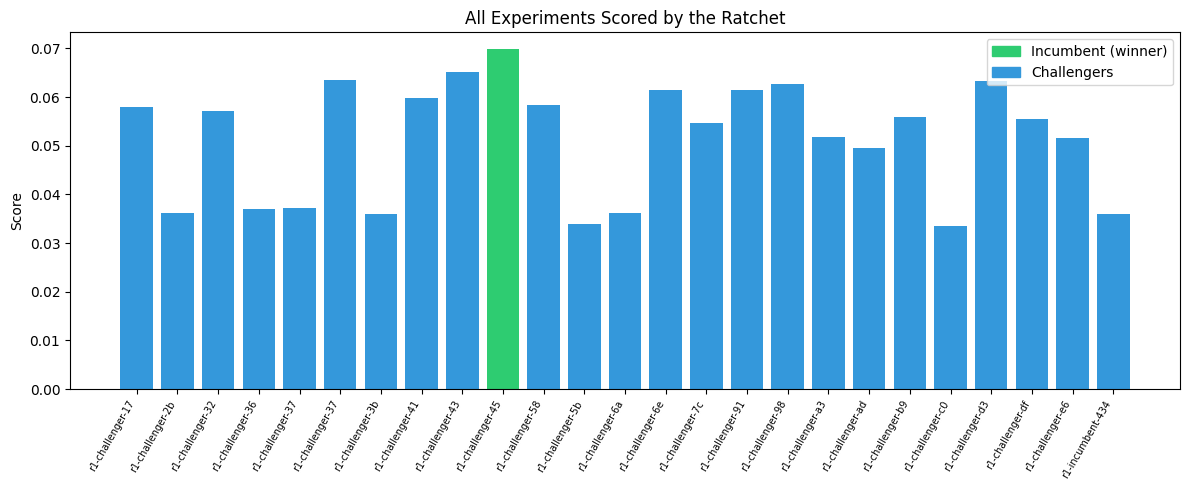

The ratchet found the best settings automatically.


In [7]:
experiments = store_rung.list_experiments(rung1_config.rung)
incumbent_id = store_rung.load_incumbent_id(rung1_config.rung)

exp_ids = [e["experiment_id"][:16] for e in experiments]
scores = [e["final_score"] for e in experiments]
colors = ["#2ecc71" if e["experiment_id"] == incumbent_id else "#3498db" for e in experiments]

plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(scores)), scores, color=colors)
plt.xticks(range(len(scores)), exp_ids, rotation=60, ha="right", fontsize=7)
plt.ylabel("Score")
plt.title("All Experiments Scored by the Ratchet")
plt.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color="#2ecc71", label="Incumbent (winner)"),
        plt.Rectangle((0,0),1,1, color="#3498db", label="Challengers"),
    ],
    loc="upper right"
)
plt.tight_layout()
plt.show()

print("The ratchet found the best settings automatically.")

In [ ]:
predict_choice(tracker, "p1_q2_score_spread",
    question="Looking at the score landscape: is there a large spread between the best and worst experiments?",
    options=[
        "No \u2014 all experiments score roughly the same",
        "Yes \u2014 there is significant variation, meaning parameter choice matters a lot",
        "Impossible to tell from a bar chart",
    ],
    correct=1, section="Pass 1: Demo", bloom="understand",
    explanation="Parameter choice strongly affects the score. This is why optimization matters.")

checkpoint_summary(tracker, "Pass 1: Demo")

## Questions You Should Have Right Now

- What is a "score"?
- What are "challengers"?
- What is this circuit actually *doing*?
- What do "verification", "postselection", and "witness" mean?
- How does the ratchet decide one experiment is better than another?

**Good -- Pass 2 answers all of these.**

---
# Pass 2: Opening the Black Box

Now we rewind and build understanding from the ground up, but always connecting back to what we saw in Pass 1.

## 2.1 The Quantum State: The Magic T-State

A **magic state** is a specific quantum state needed for universal fault-tolerant quantum computation. The T-state is:

$$|T\rangle = \frac{|0\rangle + e^{i\pi/4}|1\rangle}{\sqrt{2}}$$

This state is "magic" because it cannot be created by the cheap Clifford gates alone. If you can prepare it reliably, you unlock the full power of quantum computing. The whole point of this project is to prepare this state *inside an error-detecting code*.

T-state amplitudes: [0.70710678+0.j  0.5       +0.5j]
Expected: [1/sqrt(2), e^(i*pi/4)/sqrt(2)] = [0.7071, 0.5000+0.5000j]


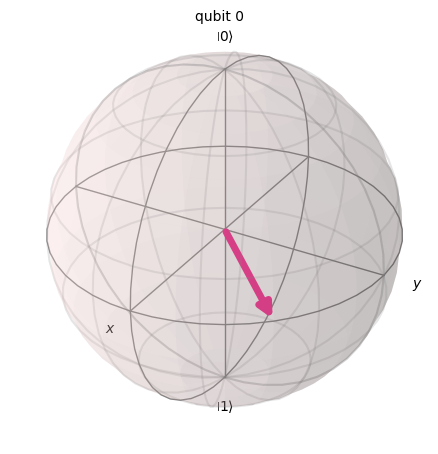

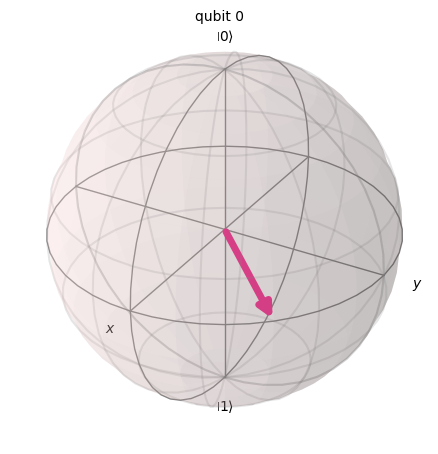

In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi, sqrt

# Build |T> on a single qubit
qc_t = QuantumCircuit(1)
qc_t.h(0)
qc_t.p(pi/4, 0)

t_state = Statevector.from_instruction(qc_t)
print("T-state amplitudes:", t_state.data)
print(f"Expected: [1/sqrt(2), e^(i*pi/4)/sqrt(2)] = [{1/sqrt(2):.4f}, {np.exp(1j*pi/4)/sqrt(2):.4f}]")

plot_bloch_multivector(t_state)

In [ ]:
quiz(tracker, "p2_q1_tstate",
    question="The T-state amplitude on |1\u27E9 has a specific phase. What is it?",
    options=["\u03C0/2 (90\u00b0)", "\u03C0/4 (45\u00b0)", "\u03C0/8 (22.5\u00b0)"],
    correct=1, section="Pass 2: Concepts", bloom="remember",
    explanation="The phase is \u03C0/4 = 45\u00b0. The gate is called T (for \u03C0/8) because of Bloch sphere conventions.")

> **Key Insight:** The T-state sits at a specific angle on the Bloch sphere (latitude $\pi/4$ from the equator in the X-Y plane). Its special position is what makes it "magic" -- it lies outside the stabilizer polytope.

## 2.2 The Encoding: [[4,2,2]] Error-Detecting Code

The [[4,2,2]] code uses **4 physical qubits** to encode **2 logical qubits**, with a code distance of 2 (can detect 1 error). We place our magic state on logical qubit 0 and the spectator state $|+\rangle$ on logical qubit 1.

The `build_preparation_circuit()` function creates this encoded state.

Circuit qubits: 4
Circuit depth:  7


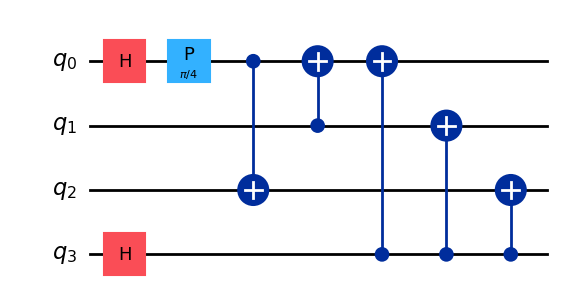

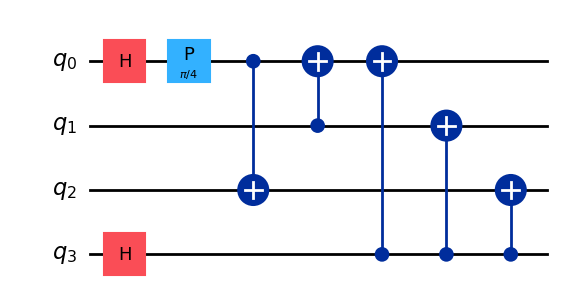

In [7]:
from autoresearch_quantum.codes.four_two_two import (
    build_preparation_circuit, build_encoder, apply_magic_seed,
    encoded_magic_statevector, STABILIZERS, MEASUREMENT_OPERATORS, DATA_QUBITS,
)

prep = build_preparation_circuit(seed_style="h_p", encoder_style="cx_chain")
print(f"Circuit qubits: {prep.num_qubits}")
print(f"Circuit depth:  {prep.depth()}")
prep.draw(output="mpl", style="iqp")

> **Key Insight:** The first gate (H + P on qubit 0) prepares the raw T-state. The remaining CNOT gates "spread" it across all 4 qubits so that single errors become detectable.

## 2.3 Stabilizer Check: Verifying the Codeword

The [[4,2,2]] code has two stabilizers: $XXXX$ and $ZZZZ$. A valid codeword must be a $+1$ eigenstate of both.

$$\langle XXXX \rangle = +1 \quad \text{and} \quad \langle ZZZZ \rangle = +1$$

In [8]:
from qiskit.quantum_info import SparsePauliOp

encoded_state = encoded_magic_statevector()

for name, op in STABILIZERS.items():
    expectation = encoded_state.expectation_value(op)
    print(f"<{name}> = {expectation.real:+.6f}")

print("\nBoth are +1 -- the state is a valid codeword!")

<z_stabilizer> = +1.000000
<x_stabilizer> = +1.000000

Both are +1 -- the state is a valid codeword!


In [ ]:
quiz(tracker, "p2_q2_stabilizer",
    question="Both stabilizer expectations are +1. What does this confirm?",
    options=[
        "The state has high energy",
        "The state is in the [[4,2,2]] codespace \u2014 no errors detected",
        "All qubits are in |0\u27E9",
    ],
    correct=1, section="Pass 2: Concepts", bloom="understand",
    explanation="Stabilizer eigenvalue +1 is the codespace condition. Any single-qubit error would flip at least one to \u22121.")

> **Key Insight:** Stabilizer eigenvalues act as error flags. If an error flips one from +1 to -1, we *detect* it (though with distance 2, we cannot correct it -- we can only discard the shot).

## 2.4 What a "Shot" Looks Like

When we run the circuit on a (simulated) quantum computer, each execution is called a "shot". The result is a bitstring that encodes both **syndrome bits** (stabilizer measurement outcomes) and **data bits** (the actual qubit readout).

In [9]:
from autoresearch_quantum.experiments.encoded_magic_state import build_circuit_bundle
from autoresearch_quantum.models import ExperimentSpec
from qiskit_aer import AerSimulator

spec_demo = ExperimentSpec(
    rung=1,
    seed_style="h_p",
    encoder_style="cx_chain",
    verification="both",
    postselection="all_measured",
    ancilla_strategy="dedicated_pair",
    shots=256,
    repeats=1,
)

bundle = build_circuit_bundle(spec_demo)
acceptance_circuit = bundle.acceptance

print(f"Registers: {[creg.name for creg in acceptance_circuit.cregs]}")
print(f"Syndrome labels: {acceptance_circuit.metadata.get('syndrome_labels', [])}")
print()

# Run on ideal simulator with memory=True to get individual shots
sim = AerSimulator()
result = sim.run(acceptance_circuit, shots=16, memory=True).result()
memory = result.get_memory(acceptance_circuit)

print("First 8 raw shots (syndrome + readout):")
for i, shot in enumerate(memory[:8]):
    parts = shot.split(" ")
    print(f"  Shot {i}: syndrome={parts[0]}, readout={parts[1]}")

Registers: ['syndrome', 'readout']
Syndrome labels: ['z_stabilizer', 'x_stabilizer']

First 8 raw shots (syndrome + readout):
  Shot 0: syndrome=1010, readout=00
  Shot 1: syndrome=0000, readout=00
  Shot 2: syndrome=1111, readout=00
  Shot 3: syndrome=0101, readout=00
  Shot 4: syndrome=1010, readout=00
  Shot 5: syndrome=0000, readout=00
  Shot 6: syndrome=1111, readout=00
  Shot 7: syndrome=1111, readout=00


The syndrome register has 2 bits: one for $ZZZZ$ and one for $XXXX$. On an ideal simulator, syndrome is always `00` (no errors detected). The readout register has 4 bits -- the measured data qubits.

> **Key Insight:** Each shot gives us a syndrome (error flag) and a data readout. We use the syndrome to decide whether to keep or discard the shot.

## 2.5 Postselection: Keeping Only Good Shots

**Postselection** means discarding shots where the syndrome indicates an error was detected. If syndrome = `00`, both stabilizers measured $+1$ and we keep the shot.

In [10]:
from autoresearch_quantum.execution.analysis import (
    local_memory_records, summarize_context, logical_magic_witness, stability_score
)

# Run with more shots for statistics
result_256 = sim.run(acceptance_circuit, shots=256, memory=True).result()
memory_256 = result_256.get_memory(acceptance_circuit)

creg_names = [creg.name for creg in acceptance_circuit.cregs]
records = local_memory_records(memory_256, creg_names)

syndrome_labels = list(acceptance_circuit.metadata.get("syndrome_labels", []))
summary = summarize_context(
    records,
    syndrome_labels=syndrome_labels,
    postselection="all_measured",
    operator=None,
)

print(f"Total shots:    {summary['total_shots']}")
print(f"Accepted shots: {summary['accepted_shots']}")
print(f"Acceptance rate: {summary['acceptance_rate']:.4f}")
print(f"\nSyndrome distribution: {summary['syndrome_counts']}")
print("\n(On an ideal simulator, acceptance rate should be 1.0 -- no errors!)")

Total shots:    256
Accepted shots: 256
Acceptance rate: 1.0000

Syndrome distribution: {'00': 256}

(On an ideal simulator, acceptance rate should be 1.0 -- no errors!)


In [ ]:
quiz(tracker, "p2_q3_postselection",
    question="Postselection improves quality by discarding error-flagged shots. What is the cost?",
    options=[
        "It makes the circuit deeper",
        "You lose shots \u2014 fewer usable data points",
        "It introduces new types of errors",
    ],
    correct=1, section="Pass 2: Concepts", bloom="understand",
    explanation="Postselection trades quantity for quality. Fewer usable shots means worse statistics or more total shots needed.")

## 2.6 Adding Noise: What Happens on Real Hardware

Real quantum processors have gate errors, readout errors, and decoherence. We simulate this using a noise model extracted from IBM's `fake_brisbane` backend.

Noisy acceptance rate: 0.7656
Ideal acceptance rate: 1.0000

Noise dropped acceptance by 0.2344


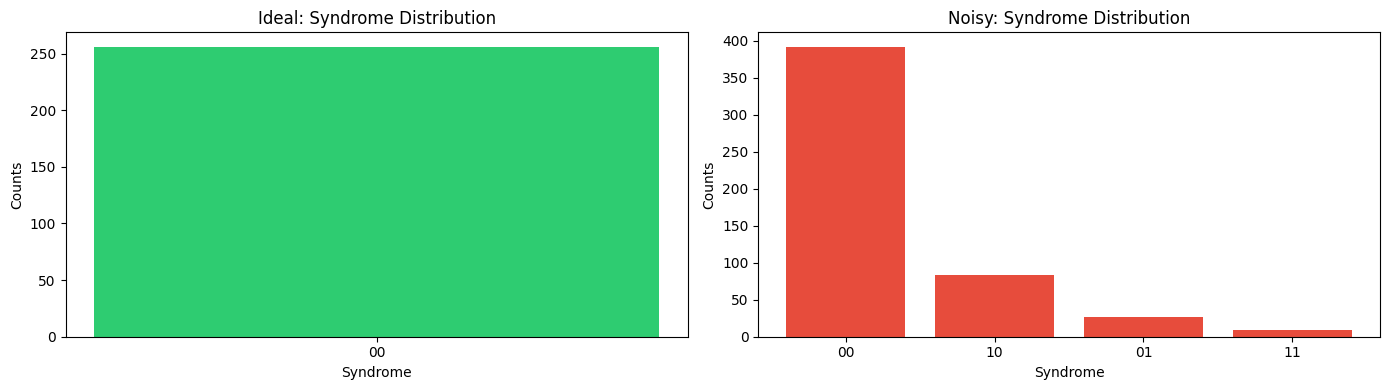

In [11]:
from autoresearch_quantum.execution.backends import resolve_backend
from autoresearch_quantum.execution.transpile import transpile_circuits
from qiskit_aer.noise import NoiseModel
from qiskit.visualization import plot_histogram

backend = resolve_backend("fake_brisbane")
noise_model = NoiseModel.from_backend(backend)

noisy_sim = AerSimulator(
    noise_model=noise_model,
    basis_gates=noise_model.basis_gates,
)

# Transpile for the backend
transpiled_acceptance = transpile_circuits([acceptance_circuit], spec_demo, backend)[0]

result_noisy = noisy_sim.run(transpiled_acceptance, shots=512, memory=True).result()
memory_noisy = result_noisy.get_memory(transpiled_acceptance)

records_noisy = local_memory_records(memory_noisy, [creg.name for creg in transpiled_acceptance.cregs])
summary_noisy = summarize_context(
    records_noisy,
    syndrome_labels=syndrome_labels,
    postselection="all_measured",
    operator=None,
)

print(f"Noisy acceptance rate: {summary_noisy['acceptance_rate']:.4f}")
print(f"Ideal acceptance rate: {summary['acceptance_rate']:.4f}")
print(f"\nNoise dropped acceptance by {summary['acceptance_rate'] - summary_noisy['acceptance_rate']:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(summary["syndrome_counts"].keys(), summary["syndrome_counts"].values(), color="#2ecc71")
ax1.set_title("Ideal: Syndrome Distribution")
ax1.set_xlabel("Syndrome")
ax1.set_ylabel("Counts")

ax2.bar(summary_noisy["syndrome_counts"].keys(), summary_noisy["syndrome_counts"].values(), color="#e74c3c")
ax2.set_title("Noisy: Syndrome Distribution")
ax2.set_xlabel("Syndrome")
ax2.set_ylabel("Counts")
plt.tight_layout()
plt.show()

> **Key Insight:** Noise causes some shots to fail the stabilizer check (syndrome != `00`). The error-detecting code is working -- it flags corrupted shots so we can discard them. But this comes at a cost: lower acceptance rate means we need more shots.

## 2.7 The Witness Formula: Measuring Magic

How do we know our encoded state is actually the *right* magic state and not just any codeword? We measure three logical operators and combine them into a **witness** value.

The logical operators for the [[4,2,2]] code are:
- $X_L = X_0 X_2$ (logical X on the magic qubit)
- $Y_L = Y_0 Z_1 X_2$ (logical Y on the magic qubit)
- $Z_{\text{spectator}} = Z_1 Z_2$ (logical Z on the spectator qubit)

The witness formula is:

$$\text{witness} = \underbrace{\frac{1 + \frac{\langle X_L \rangle + \langle Y_L \rangle}{\sqrt{2}}}{2}}_{\text{magic quality}} \times \underbrace{\frac{1 + \langle Z_{\text{spectator}} \rangle}{2}}_{\text{spectator alignment}}$$

In [12]:
# Measure each logical operator on the noisy simulator
witness_circuits = bundle.witness_circuits
transpiled_witnesses = {}
for name, circ in witness_circuits.items():
    transpiled_witnesses[name] = transpile_circuits([circ], spec_demo, backend)[0]

expectations = {}
for name, circ in transpiled_witnesses.items():
    result_w = noisy_sim.run(circ, shots=512, memory=True).result()
    mem_w = result_w.get_memory(circ)
    recs_w = local_memory_records(mem_w, [creg.name for creg in circ.cregs])
    summary_w = summarize_context(
        recs_w,
        syndrome_labels=syndrome_labels,
        postselection="all_measured",
        operator=MEASUREMENT_OPERATORS.get(name),
    )
    expectations[name] = summary_w["expectation"]
    print(f"<{name:>14}> = {summary_w['expectation']:+.4f}  (acceptance: {summary_w['acceptance_rate']:.4f})")

# Build up the witness step by step
lx = expectations["logical_x"]
ly = expectations["logical_y"]
sz = expectations["spectator_z"]

magic_quality = (1.0 + (lx + ly) / sqrt(2)) / 2.0
spectator_alignment = (1.0 + sz) / 2.0
witness_value = magic_quality * spectator_alignment

# Also compute via the library function
witness_lib = logical_magic_witness(lx, ly, sz)

print(f"\n--- Witness Computation ---")
print(f"  (X_L + Y_L) / sqrt(2) = ({lx:.4f} + {ly:.4f}) / {sqrt(2):.4f} = {(lx + ly)/sqrt(2):.4f}")
print(f"  Magic quality   = (1 + {(lx+ly)/sqrt(2):.4f}) / 2 = {magic_quality:.4f}")
print(f"  Spectator align = (1 + {sz:.4f}) / 2 = {spectator_alignment:.4f}")
print(f"  Witness = {magic_quality:.4f} x {spectator_alignment:.4f} = {witness_value:.4f}")
print(f"  Library check:  {witness_lib:.4f}")

<     logical_x> = +0.5071  (acceptance: 0.5469)
<     logical_y> = +0.3569  (acceptance: 0.6621)
<   spectator_z> = +0.0000  (acceptance: 0.5312)

--- Witness Computation ---
  (X_L + Y_L) / sqrt(2) = (0.5071 + 0.3569) / 1.4142 = 0.6110
  Magic quality   = (1 + 0.6110) / 2 = 0.8055
  Spectator align = (1 + 0.0000) / 2 = 0.5000
  Witness = 0.8055 x 0.5000 = 0.4027
  Library check:  0.4027


> **Connection to Pass 1:** This witness value is the `logical_magic_witness` field in the evaluation metrics. It is the core measure of **quality** -- the thing the ratchet was trying to maximize.

## 2.8 Cost: Why Circuit Complexity Matters

Longer circuits accumulate more errors. The cost function penalizes experiments with many two-qubit gates, deep circuits, and large shot counts.

In [13]:
from autoresearch_quantum.execution.transpile import count_two_qubit_gates, circuit_metadata

for name, circ in transpiled_witnesses.items():
    tqg = count_two_qubit_gates(circ)
    d = circ.depth()
    meta = circuit_metadata(circ, spec_demo)
    print(f"{name:>14}: depth={d:3d}, two-qubit gates={tqg:3d}, size={meta['size']}")

# Show the cost formula
print(f"\nCost formula from rung1 config:")
cw = rung1_config.score.cost_weights
print(f"  cost = {rung1_config.score.base_cost} + {cw.two_qubit_count}*two_q + {cw.depth}*depth + {cw.shot_count}*shots + {cw.runtime_estimate}*runtime + {cw.queue_cost_proxy}*queue")

     logical_x: depth= 83, two-qubit gates= 30, size=192
     logical_y: depth= 93, two-qubit gates= 30, size=184
   spectator_z: depth=108, two-qubit gates= 32, size=209

Cost formula from rung1 config:
  cost = 1.0 + 0.08*two_q + 0.01*depth + 0.0002*shots + 0.015*runtime + 0.3*queue


In [ ]:
predict_choice(tracker, "p2_q4_cost_quality",
    question="More complex circuits might give better quality but higher cost. What does the score formula do with this tension?",
    options=[
        "Ignores cost entirely \u2014 only quality matters",
        "Divides quality by cost, so you need quality to outweigh the cost",
        "Picks the cheapest circuit regardless of quality",
    ],
    correct=1, section="Pass 2: Scoring", bloom="apply",
    explanation="score = quality \u00d7 acceptance / cost. A circuit that is 2x better but 3x more expensive scores worse.")

checkpoint_summary(tracker, "Pass 2: Scoring")

> **Key Insight:** There is a tension between quality and cost. More complex circuits might give better error detection, but they also introduce more errors. The scoring function balances this tradeoff.

## 2.9 The Score: Putting It All Together

The final score combines **quality** (witness, fidelity, stability, etc.), **acceptance rate** (fraction of shots that pass postselection), and **cost** (circuit complexity):

$$\text{score} = \frac{\text{quality} \times \text{acceptance\_rate}}{\text{cost}}$$

where quality is a weighted sum of individual metrics.

In [14]:
from autoresearch_quantum.scoring.score import score_metrics, weighted_acceptance_cost
from autoresearch_quantum.models import EvaluationMetrics

# Build metrics from our manual measurements
manual_metrics = EvaluationMetrics(
    ideal_encoded_fidelity=1.0,  # perfect on ideal sim
    noisy_encoded_fidelity=0.85,  # placeholder
    logical_magic_witness=witness_lib,
    acceptance_rate=summary_noisy["acceptance_rate"],
    codespace_rate=summary_noisy["acceptance_rate"],
    spectator_logical_z=sz,
    logical_x=lx,
    logical_y=ly,
    stability_score=1.0,
    two_qubit_count=sum(count_two_qubit_gates(c) for c in transpiled_witnesses.values()),
    depth=max(c.depth() for c in transpiled_witnesses.values()),
    shot_count=512,
)

score, quality, cost = score_metrics(manual_metrics, "cheap", rung1_config.score)

print(f"Quality:         {quality:.6f}")
print(f"Acceptance rate: {summary_noisy['acceptance_rate']:.6f}")
print(f"Cost:            {cost:.6f}")
print(f"Score:           {score:.6f}")
print(f"\nScore = {quality:.4f} * {summary_noisy['acceptance_rate']:.4f} / {cost:.4f} = {score:.6f}")

Quality:         0.730531
Acceptance rate: 0.765625
Cost:            9.542400
Score:           0.058613

Score = 0.7305 * 0.7656 / 9.5424 = 0.058613


> **Connection to Pass 1:** This is exactly the score number you saw in the bar chart. Every bar in that chart was computed using this formula.

## 2.10 What Are Challengers?

The ratchet starts with an **incumbent** (the current best experiment settings). It then generates **challengers** by mutating one or more parameters. Each challenger is evaluated and compared to the incumbent.

In [15]:
from autoresearch_quantum.search.challengers import generate_neighbor_challengers, mutation_summary

incumbent_spec = rung1_config.bootstrap_incumbent
print("Incumbent settings:")
print(f"  seed_style:        {incumbent_spec.seed_style}")
print(f"  encoder_style:     {incumbent_spec.encoder_style}")
print(f"  verification:      {incumbent_spec.verification}")
print(f"  postselection:     {incumbent_spec.postselection}")
print(f"  ancilla_strategy:  {incumbent_spec.ancilla_strategy}")
print(f"  optimization_level:{incumbent_spec.optimization_level}")

# Generate challengers
challengers = generate_neighbor_challengers(incumbent_spec, rung1_config.search_space)

print(f"\nGenerated {len(challengers)} challengers:")
print(f"{'#':>3}  {'Mutation':50s}")
print("-" * 55)
for i, ch in enumerate(challengers):
    print(f"{i+1:3d}  {ch.mutation_note}")

Incumbent settings:
  seed_style:        h_p
  encoder_style:     cx_chain
  verification:      both
  postselection:     all_measured
  ancilla_strategy:  dedicated_pair
  optimization_level:2

Generated 8 challengers:
  #  Mutation                                          
-------------------------------------------------------
  1  seed_style: h_p -> ry_rz
  2  seed_style: h_p -> u_magic
  3  encoder_style: cx_chain -> cz_compiled
  4  verification: both -> z_only
  5  verification: both -> x_only
  6  postselection: all_measured -> z_only
  7  postselection: all_measured -> none
  8  ancilla_strategy: dedicated_pair -> reused_single


In [ ]:
quiz(tracker, "p2_q5_neighbors",
    question="Each NeighborWalk challenger differs from the incumbent in how many parameters?",
    options=["0", "1", "2", "All of them"],
    correct=1, section="Pass 2: Ratchet", bloom="apply",
    explanation="NeighborWalk changes exactly one parameter at a time. This is systematic but cannot find parameter interactions.")

checkpoint_summary(tracker, "Pass 2: Ratchet")

Each challenger differs from the incumbent in exactly one parameter (this is the `NeighborWalk` strategy). The ratchet also uses `RandomCombo` to mutate multiple parameters at once.

In [16]:
# Evaluate a few challengers and compare
from autoresearch_quantum.execution.local import LocalCheapExecutor

executor = LocalCheapExecutor()

print(f"{'Setting':45s} {'Score':>10s} {'Quality':>10s} {'Accept':>10s}")
print("-" * 80)

# Evaluate incumbent
inc_result = executor.evaluate(incumbent_spec, rung1_config)
print(f"{'INCUMBENT':45s} {inc_result.score:10.6f} {inc_result.quality_estimate:10.6f} {inc_result.metrics.acceptance_rate:10.4f}")

# Evaluate first 4 challengers
for ch in challengers[:4]:
    ch_result = executor.evaluate(ch.spec, rung1_config)
    label = ch.mutation_note[:45]
    print(f"{label:45s} {ch_result.score:10.6f} {ch_result.quality_estimate:10.6f} {ch_result.metrics.acceptance_rate:10.4f}")

Setting                                            Score    Quality     Accept
--------------------------------------------------------------------------------
INCUMBENT                                       0.035552   0.851271     1.0000
seed_style: h_p -> ry_rz                        0.035362   0.854142     1.0000
seed_style: h_p -> u_magic                      0.036333   0.853074     1.0000
encoder_style: cx_chain -> cz_compiled          0.035371   0.841448     1.0000
verification: both -> z_only                    0.069126   0.855724     1.0000


> **Connection to Pass 1:** In Pass 1, the ratchet did this automatically -- generated challengers, evaluated all of them, and picked the best.

## 2.11 Promotion and Winner Selection

Not every challenger becomes the new incumbent. The ratchet uses a **cheap margin** to filter: a challenger must beat the incumbent's score by at least this threshold.

$$\text{challenger\_score} > \text{incumbent\_score} + \text{cheap\_margin}$$

Only the top-K challengers that clear this bar get "promoted". The best one among promoted challengers (and the incumbent) becomes the new incumbent.

In [17]:
cheap_margin = rung1_config.tier_policy.cheap_margin
promote_top_k = rung1_config.tier_policy.promote_top_k

print(f"Cheap margin:   {cheap_margin}")
print(f"Promote top-K:  {promote_top_k}")
print(f"\nIncumbent score: {inc_result.score:.6f}")
print(f"Threshold:       {inc_result.score + cheap_margin:.6f}")
print(f"\nFor a challenger to be promoted, it must score above {inc_result.score + cheap_margin:.6f}")

Cheap margin:   0.002
Promote top-K:  2

Incumbent score: 0.035552
Threshold:       0.037552

For a challenger to be promoted, it must score above 0.037552


## 2.12 Re-Running the Ratchet Step (With Understanding)

Let's run the same ratchet step from Pass 1, but now we understand every decision.

In [18]:
# Fresh store
store_p2 = ResearchStore(tempfile.mkdtemp())
harness_p2 = AutoresearchHarness(store_p2)

# Ensure incumbent
incumbent_record = harness_p2.ensure_incumbent(rung1_config)
print(f"Incumbent ID:    {incumbent_record.experiment_id}")
print(f"Incumbent score: {incumbent_record.cheap_result.score:.6f}")
print(f"  witness:  {incumbent_record.cheap_result.metrics.logical_magic_witness:.4f}")
print(f"  accept:   {incumbent_record.cheap_result.metrics.acceptance_rate:.4f}")
print(f"  cost:     {incumbent_record.cheap_result.metrics.total_cost:.4f}")

# Run challenger set
print("\n--- Running challengers ---")
challenger_records = harness_p2.run_challenger_set(rung1_config)

print(f"\n{'ID':>24s}  {'Score':>10s}  {'Margin':>10s}  {'Promoted?':>10s}  Mutation")
print("-" * 95)
for rec in sorted(challenger_records, key=lambda r: r.cheap_result.score, reverse=True):
    margin = rec.cheap_result.score - incumbent_record.cheap_result.score
    promoted = "YES" if margin > cheap_margin else "no"
    print(f"{rec.experiment_id[:24]:>24s}  {rec.cheap_result.score:10.6f}  {margin:+10.6f}  {promoted:>10s}  {rec.mutation_note[:40]}")

Incumbent ID:    r1-incumbent-4343a2eac0
Incumbent score: 0.035164
  witness:  0.5105
  accept:   1.0000
  cost:     24.2192

--- Running challengers ---

                      ID       Score      Margin   Promoted?  Mutation
-----------------------------------------------------------------------------------------------
r1-challenger-49ab8874a8    0.068216   +0.033052         YES  combo: postselection: all_measured -> z_
r1-challenger-b8c950b594    0.053963   +0.018798         YES  combo: encoder_style: cx_chain -> cz_com
r1-challenger-a39c019eb7    0.048566   +0.013402         YES  combo: verification: both -> z_only, opt
r1-challenger-6a036b7f5f    0.036716   +0.001551          no  neighbor: seed_style: h_p -> u_magic
r1-challenger-045a4145b4    0.036413   +0.001249          no  combo: postselection: all_measured -> z_
r1-challenger-49ccceae73    0.035814   +0.000650          no  combo: encoder_style: cx_chain -> cz_com
r1-challenger-2bc9c87de9    0.035086   -0.000078          no  ne

> **Connection to Pass 1:** You are now seeing the same optimization process from Pass 1, but with full visibility into the scores, margins, and promotion decisions.

## 2.13 The Lesson Revisited

Let's re-read the lesson from our Pass 1 rung. Now every term should make sense.

In [19]:
display(Markdown(lesson.narrative))

print("\n--- Now you know what each term means ---")
print("- 'verification=both' means measuring both XXXX and ZZZZ stabilizers")
print("- 'logical witness' is the magic_quality x spectator_alignment formula")
print("- 'acceptance rate' is the fraction of shots where syndrome=00")
print("- 'score' = quality * acceptance / cost")
print("- 'mean score improved by +X' means a challenger beat the incumbent")

NameError: name 'Markdown' is not defined

---
# Pass 3: Making It Your Own

You have seen the system run (Pass 1) and understood every component (Pass 2). Now you will **drive** -- modify parameters, compare scoring functions, and run multi-step optimizations.

## 3.1 Change the Search Space

What if we restrict the search to only a few dimensions? Or expand it? Let's modify the rung config and see how the challengers change.

In [ ]:
from dataclasses import replace
from autoresearch_quantum.models import SearchSpaceConfig

# Create a search space that only explores verification and postselection
narrow_space = SearchSpaceConfig(
    dimensions={
        "verification": ["both", "z_only", "x_only"],
        "postselection": ["all_measured", "z_only", "none"],
    },
    max_challengers_per_step=6,
)

narrow_config = replace(rung1_config, search_space=narrow_space, step_budget=2, patience=2)

# Run a ratchet step with this narrower search
store_narrow = ResearchStore(tempfile.mkdtemp())
harness_narrow = AutoresearchHarness(store_narrow)
step_narrow = harness_narrow.run_ratchet_step(narrow_config)

print(f"Challengers tested: {len(step_narrow.challengers_tested)}")
print(f"Winner: {step_narrow.winner_id}")
print(f"Margin: {step_narrow.winning_margin:+.6f}")
print(f"Lesson: {step_narrow.distilled_lesson}")

# Show which experiments were tried
exps_narrow = store_narrow.list_experiments(1)
for e in exps_narrow:
    role = e["role"]
    v = e["spec"]["verification"]
    p = e["spec"]["postselection"]
    s = e["final_score"]
    print(f"  {role:12s}  verification={v:12s}  postselection={p:14s}  score={s:.6f}")

## 3.2 Compare Scoring Functions

The system supports multiple scoring functions. `weighted_acceptance_cost` balances quality and cost traditionally. `factory_throughput` optimizes for accepted magic states per unit cost, penalizing circuit complexity more heavily.

In [ ]:
from autoresearch_quantum.scoring.score import weighted_acceptance_cost, factory_throughput_score
from autoresearch_quantum.models import ScoreConfig

# Evaluate the same set of specs with both scoring functions
test_specs = [
    rung1_config.bootstrap_incumbent,
    rung1_config.bootstrap_incumbent.with_updates(verification="z_only"),
    rung1_config.bootstrap_incumbent.with_updates(verification="x_only"),
    rung1_config.bootstrap_incumbent.with_updates(postselection="none"),
    rung1_config.bootstrap_incumbent.with_updates(encoder_style="cz_compiled"),
]

labels = ["baseline", "z_only_verif", "x_only_verif", "no_postsel", "cz_compiled"]

wac_scores = []
ft_scores = []

factory_score_config = replace(rung1_config.score, name="factory_throughput")

for spec_test in test_specs:
    result_test = executor.evaluate(spec_test, rung1_config)
    metrics = result_test.metrics
    
    s_wac, _, _ = weighted_acceptance_cost(metrics, "cheap", rung1_config.score)
    # Need fresh metrics for factory scoring since it modifies metrics.extra
    result_test2 = executor.evaluate(spec_test, rung1_config)
    s_ft, _, _ = factory_throughput_score(result_test2.metrics, "cheap", factory_score_config)
    
    wac_scores.append(s_wac)
    ft_scores.append(s_ft)

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(x, wac_scores, width, color="#3498db", label="weighted_acceptance_cost")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha="right")
ax1.set_ylabel("Score")
ax1.set_title("weighted_acceptance_cost")

ax2.bar(x, ft_scores, width, color="#e67e22", label="factory_throughput")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=30, ha="right")
ax2.set_ylabel("Score")
ax2.set_title("factory_throughput")

plt.tight_layout()
plt.show()

# Show ranking differences
wac_rank = np.argsort(wac_scores)[::-1]
ft_rank = np.argsort(ft_scores)[::-1]
print("Ranking by weighted_acceptance_cost:", [labels[i] for i in wac_rank])
print("Ranking by factory_throughput:      ", [labels[i] for i in ft_rank])

In [ ]:
reflect(tracker, "p3_q1_scoring_choice",
    question="You see that different scoring functions rank experiments differently. When would you choose factory throughput over WAC?",
    section="Pass 3: Scoring", bloom="evaluate",
    model_answer="Factory throughput penalizes cost more heavily. Use it when you are producing many T-states in a pipeline and throughput matters more than per-state quality.")

> **Key Insight:** Different scoring functions can re-order the rankings. The factory throughput scorer penalizes circuit complexity more heavily, which can favor simpler circuits even if their raw quality is slightly lower.

## 3.3 Run a Full Multi-Step Rung and Visualize the Trajectory

Let's run a full rung with `step_budget=3` and watch the score evolve over steps. The patience mechanism will stop early if the ratchet stalls.

In [ ]:
store_multi = ResearchStore(tempfile.mkdtemp())
harness_multi = AutoresearchHarness(store_multi)

config_multi = replace(rung1_config, step_budget=3, patience=2)
steps_multi, lesson_multi, feedback_multi = harness_multi.run_rung(config_multi)

# Extract trajectory
step_indices = [s.step_index for s in steps_multi]
winning_margins = [s.winning_margin for s in steps_multi]
winner_ids = [s.winner_id[:16] for s in steps_multi]

# Get incumbent score at each step by loading experiment
incumbent_scores = []
for s in steps_multi:
    exp_data = store_multi.load_experiment(1, s.winner_id)
    incumbent_scores.append(exp_data["final_score"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(step_indices, incumbent_scores, "o-", color="#2ecc71", linewidth=2, markersize=8)
ax1.set_xlabel("Step")
ax1.set_ylabel("Winner Score")
ax1.set_title("Score Trajectory Over Ratchet Steps")
ax1.grid(True, alpha=0.3)

colors_margin = ["#2ecc71" if m > 0 else "#e74c3c" for m in winning_margins]
ax2.bar(step_indices, winning_margins, color=colors_margin)
ax2.axhline(y=0, color="black", linewidth=0.5)
ax2.set_xlabel("Step")
ax2.set_ylabel("Winning Margin")
ax2.set_title("Margin Over Previous Incumbent")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Steps completed: {len(steps_multi)} / {config_multi.step_budget}")
for s in steps_multi:
    print(f"  Step {s.step_index}: margin={s.winning_margin:+.6f}  challengers={len(s.challengers_tested)}  promoted={len(s.promoted_challengers)}")

### &#9997; Code Challenge

Write code to compute the **cumulative best score** at each step of the multi-step rung.
That is, for each step, track the highest score seen so far.

## 3.4 Visualize the Exploration Path

For each step, what parameter changed and by how much did the score shift?

In [ ]:
# Collect step-by-step exploration data
ratchet_steps_data = store_multi.list_ratchet_steps(1)

print(f"{'Step':>5s}  {'Winner':>20s}  {'Margin':>10s}  {'Lesson (first 80 chars)'}")
print("-" * 120)
for step_data in ratchet_steps_data:
    print(
        f"{step_data['step_index']:5d}  "
        f"{step_data['winner_id'][:20]:>20s}  "
        f"{step_data['winning_margin']:+10.6f}  "
        f"{step_data['distilled_lesson'][:80]}"
    )

# Show all experiments as a parameter heatmap
all_exps = store_multi.list_experiments(1)
dimensions = list(rung1_config.search_space.dimensions.keys())

print(f"\n{'ID':>20s}  {'Score':>10s}  {'Role':>12s}", end="")
for d in dimensions[:4]:
    print(f"  {d:>18s}", end="")
print()
print("-" * 110)
for e in sorted(all_exps, key=lambda x: x["final_score"], reverse=True)[:10]:
    print(f"{e['experiment_id'][:20]:>20s}  {e['final_score']:10.6f}  {e['role']:>12s}", end="")
    for d in dimensions[:4]:
        print(f"  {str(e['spec'].get(d, ''))[:18]:>18s}", end="")
    print()

## 3.5 Search Strategies Head-to-Head

The system uses three search strategies:
- **NeighborWalk**: Change one parameter at a time (systematic)
- **RandomCombo**: Change 1-3 parameters at once (exploratory)
- **LessonGuided**: Use rules from previous rungs to bias the search (adaptive)

In [ ]:
from autoresearch_quantum.search.strategies import NeighborWalk, RandomCombo, LessonGuided

incumbent_for_test = rung1_config.bootstrap_incumbent
space_for_test = rung1_config.search_space

nw = NeighborWalk()
rc = RandomCombo(num_candidates=8)

nw_challengers = nw.generate(incumbent_for_test, space_for_test, set())
rc_challengers = rc.generate(incumbent_for_test, space_for_test, set())

print(f"NeighborWalk generated {len(nw_challengers)} challengers")
print(f"RandomCombo generated  {len(rc_challengers)} challengers")

# Count mutations per dimension for each strategy
def count_dimensions(challengers):
    dim_counts = {}
    for ch in challengers:
        for dim in dimensions:
            if dim in ch.mutation_note:
                dim_counts[dim] = dim_counts.get(dim, 0) + 1
    return dim_counts

nw_dims = count_dimensions(nw_challengers)
rc_dims = count_dimensions(rc_challengers)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

if nw_dims:
    ax1.barh(list(nw_dims.keys()), list(nw_dims.values()), color="#3498db")
    ax1.set_title("NeighborWalk: Mutations per Dimension")
    ax1.set_xlabel("Count")

if rc_dims:
    ax2.barh(list(rc_dims.keys()), list(rc_dims.values()), color="#e67e22")
    ax2.set_title("RandomCombo: Mutations per Dimension")
    ax2.set_xlabel("Count")

plt.tight_layout()
plt.show()

# Show multi-dimensional mutations from RandomCombo
print("\nRandomCombo mutations (note multi-dimensional changes):")
for ch in rc_challengers[:6]:
    print(f"  {ch.mutation_note}")

In [ ]:
order(tracker, "p3_q2_strategy_comparison",
    instruction="Rank strategies by ability to find multi-parameter interactions (worst to best):",
    items=["NeighborWalk", "RandomCombo", "LessonGuided"],
    correct_order=["NeighborWalk", "LessonGuided", "RandomCombo"],
    section="Pass 3: Strategies", bloom="analyze",
    explanation="NeighborWalk: 1 axis only. LessonGuided: focused by rules. RandomCombo: multiple axes, can find synergies.")

## 3.6 Lesson-Guided Search

The `LessonGuided` strategy uses rules extracted from previous rungs. Let's create synthetic rules to see how they bias the search.

In [ ]:
from autoresearch_quantum.models import SearchRule, LessonFeedback

# Create synthetic rules: prefer z_only verification, avoid x_only
synthetic_rules = [
    SearchRule(
        dimension="verification",
        action="prefer",
        value="z_only",
        confidence=0.8,
        reason="synthetic: z_only performed best in testing",
    ),
    SearchRule(
        dimension="verification",
        action="avoid",
        value="x_only",
        confidence=0.7,
        reason="synthetic: x_only consistently underperformed",
    ),
    SearchRule(
        dimension="encoder_style",
        action="prefer",
        value="cx_chain",
        confidence=0.6,
        reason="synthetic: cx_chain has fewer two-qubit gates after transpilation",
    ),
]

synthetic_feedback = LessonFeedback(
    rung=0,
    rules=synthetic_rules,
    narrowed_dimensions={},
    best_spec_fields={},
)

lg = LessonGuided(num_candidates=8)
lg_challengers = lg.generate(
    incumbent_for_test, space_for_test, set(), lessons=[synthetic_feedback]
)

print(f"LessonGuided generated {len(lg_challengers)} challengers:")
for ch in lg_challengers:
    print(f"  {ch.mutation_note}")

# Check: does it avoid x_only?
has_x_only = any("x_only" in ch.mutation_note for ch in lg_challengers)
has_z_only = any("z_only" in ch.mutation_note for ch in lg_challengers)
print(f"\nContains x_only mutations: {has_x_only} (should be rare/absent)")
print(f"Contains z_only mutations: {has_z_only} (should be common)")

### &#9997; Code Challenge

Create a search rule that **avoids** the `"none"` postselection setting
with high confidence, and add it to the `synthetic_rules` list.

> **Key Insight:** Lesson-guided search closes the feedback loop. What the ratchet learns in one rung can guide exploration in the next, avoiding settings that already proved poor and focusing on promising regions.

## 3.7 Cross-Rung Propagation

The full `run_ratchet()` method runs multiple rungs in sequence. The winner from rung 1 bootstraps rung 2, and lessons accumulate across rungs.

In [ ]:
rung2_config = load_rung_config("../../configs/rungs/rung2.yaml")

# Use smaller budgets for speed
config_r1 = replace(rung1_config, step_budget=2, patience=2)
config_r2 = replace(rung2_config, step_budget=2, patience=2)

store_cross = ResearchStore(tempfile.mkdtemp())
harness_cross = AutoresearchHarness(store_cross)

print("Running cross-rung ratchet (rung1 -> rung2)...")
results = harness_cross.run_ratchet([config_r1, config_r2])

for lesson_obj, fb in results:
    print(f"\n{'='*60}")
    print(f"Rung {lesson_obj.rung}: {lesson_obj.name}")
    print(f"  What helped:    {lesson_obj.what_helped[:2]}")
    print(f"  What hurt:      {lesson_obj.what_hurt[:2]}")
    print(f"  Rules learned:  {len(fb.rules)}")
    if fb.best_spec_fields:
        print(f"  Best spec seed: {fb.best_spec_fields.get('seed_style', '?')}")
        print(f"  Best spec verif: {fb.best_spec_fields.get('verification', '?')}")

## 3.8 Transfer Evaluation

How well does a winning spec perform across different backend noise profiles? The `TransferEvaluator` tests a single spec on multiple backends and reports the pessimistic (minimum) score.

In [ ]:
from autoresearch_quantum.execution.transfer import TransferEvaluator

# Get the rung1 winner
winner_id = store_cross.load_incumbent_id(1)
winner_data = store_cross.load_experiment(1, winner_id)
winner_spec = ExperimentSpec(**{
    k: tuple(v) if k == "initial_layout" and isinstance(v, list) else v
    for k, v in winner_data["spec"].items()
})

# Evaluate on a single additional backend
transfer_eval = TransferEvaluator()
report = transfer_eval.evaluate_across_backends(
    winner_spec,
    backends=["fake_brisbane", "fake_kyoto"],
    rung_config=config_r1,
)

print(f"Transfer Evaluation Report")
print(f"{'='*50}")
print(f"Spec fingerprint: {winner_spec.fingerprint()}")
print(f"\nPer-backend scores:")
for bk, sc in report.per_backend_scores.items():
    print(f"  {bk:20s}: {sc:.6f}")
print(f"\nMean score:     {report.mean_score:.6f}")
print(f"Min score:      {report.min_score:.6f}")
print(f"Max score:      {report.max_score:.6f}")
print(f"Std score:      {report.std_score:.6f}")
print(f"Transfer score: {report.transfer_score:.6f} (pessimistic = min)")

In [ ]:
quiz(tracker, "p3_q3_transfer",
    question="A spec scores 0.8 on fake_brisbane but 0.3 on a different backend. What does this tell you?",
    options=[
        "The spec is bad",
        "The spec is overfitted to fake_brisbane's specific noise profile",
        "The other backend is broken",
    ],
    correct=1, section="Pass 3: Transfer", bloom="evaluate",
    explanation="A large score drop on transfer means the settings were tuned to one backend's quirks rather than being generally good.")

checkpoint_summary(tracker, "Pass 3: Transfer")

> **Key Insight:** A spec that scores well on one backend may score poorly on another. The transfer score (minimum across backends) prevents overfitting to a single noise profile. This is crucial for real quantum computing where hardware changes day to day.

## 3.9 Your Own Experiment

Here is a template for you to create and evaluate your own experiment. Modify the spec fields, run it, and see how your design compares to the ratchet's winner.

In [ ]:
# === YOUR EXPERIMENT ===
# Modify these parameters and re-run the cell!

my_spec = ExperimentSpec(
    rung=1,
    seed_style="ry_rz",          # Try: "h_p", "ry_rz", "u_magic"
    encoder_style="cx_chain",     # Try: "cx_chain", "cz_compiled"
    verification="both",          # Try: "both", "z_only", "x_only"
    postselection="all_measured", # Try: "all_measured", "z_only", "none"
    ancilla_strategy="dedicated_pair",  # Try: "dedicated_pair", "reused_single"
    optimization_level=2,         # Try: 1, 2, 3
    layout_method="sabre",
    routing_method="sabre",
    target_backend="fake_brisbane",
    noise_backend="fake_brisbane",
    shots=256,
    repeats=1,
)

my_result = executor.evaluate(my_spec, rung1_config)

print(f"Your Experiment Results")
print(f"{'='*50}")
print(f"Score:            {my_result.score:.6f}")
print(f"Quality:          {my_result.quality_estimate:.6f}")
print(f"Acceptance rate:  {my_result.metrics.acceptance_rate:.4f}")
print(f"Magic witness:    {my_result.metrics.logical_magic_witness:.4f}")
print(f"Spectator Z:      {my_result.metrics.spectator_logical_z:.4f}")
print(f"Two-qubit gates:  {my_result.metrics.two_qubit_count}")
print(f"Depth:            {my_result.metrics.depth}")
print(f"Total cost:       {my_result.metrics.total_cost:.4f}")
print(f"Failure mode:     {my_result.metrics.dominant_failure_mode}")

# Compare to the ratchet winner
print(f"\nRatchet winner score: {winner_data['final_score']:.6f}")
delta = my_result.score - winner_data['final_score']
print(f"Your delta:           {delta:+.6f} {'(you win!)' if delta > 0 else '(ratchet wins)'}")

### &#9997; Code Challenge

Modify the experiment spec above, evaluate it, and check whether your custom spec
beats the rung1 default incumbent score. Set `my_spec_beats_default` to `True` if it does.

## Summary

You have now seen the same system three times.

**The first time was magic** -- you pushed a button and an optimizer ran, producing scores, winners, and a lesson narrative. You had no idea what any of it meant.

**The second time was science** -- you built the T-state from scratch, understood stabilizers, measured the witness, computed the score by hand, and saw how challengers compete. Every number from Pass 1 had a concrete physical meaning.

**The third time was engineering** -- you modified the search space, compared scoring functions, ran multi-rung optimizations, tested transfer across backends, and designed your own experiment.

This is the spiral: each pass through the same material reveals structure that was invisible before. The ratchet itself works the same way -- each step builds on what came before, ratcheting toward better and better quantum experiments.

---
## Final Assessment

In [ ]:
tracker.dashboard()
path = tracker.save()
print(f"\nProgress saved to: {path}")